<a href="https://colab.research.google.com/github/4llsee/Layanapp/blob/main/titanic_prediction_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Selected Topic in Artificcial Intelligence -Project

This project utilizes the famous Titanic dataset was used to predict passengers' survival based on features such as age, gender, ticket class, and fare.
The XGBoost algorithm was applied due to its strong performance in classification tasks and its ability to handle complex data structures.
Data preprocessing involved converting categorical variables into numerical ones, followed by splitting the dataset into training and testing sets to evaluate the model’s performance.
The results showed good accuracy, with potential for further improvement through enhanced preprocessing and feature importance analysis.

In [ ]:
!pip install -q xgboost

-Importing necessary libraries
-Loading the Titanic dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('titanic.csv')

df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Data preprocessing and cleaning
معالجة وتنظيف البيانات (تحويل المتغيرات النصية إلى عددية ومعالجة القيم المفقودة)

In [ ]:
# تحويل الأعمدة النصية إلى قيم عددية باستخدام LabelEncoder
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Embarked'] = label_encoder.fit_transform(df['Embarked'].fillna('S'))
df['Age'].fillna(df['Age'].mean(), inplace=True)
df = df[['Pclass', 'Age', 'Sex', 'Fare', 'Embarked', 'Survived']]
df.head()

<ipython-input-9-73ab9c4926d2>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


,Pclass,Age,Sex,Fare,Embarked,Survived
0,3,22.0,1,7.2500,2,0
1,1,38.0,0,71.2833,0,1
2,3,26.0,0,7.9250,2,1
3,1,35.0,0,53.1000,2,1
4,3,35.0,1,8.0500,2,0


# Splitting the dataset into training and testing sets
تقسيم البيانات إلى مجموعة تدريب ومجموعة اختبار

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training the XGBoost model
تدريب نموذج XGBoost على بيانات التدريب

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

# Evaluating the model's accuracy
تقييم دقة النموذج على بيانات الاختبار

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Accuracy: 78.77%
Confusion Matrix:
[[86 19]
 [19 55]]


Calculating additional evaluation metrics (Precision, Recall, F1-Score)
حساب مقاييس تقييم إضافية (الدقة، الاستدعاء، F1-Score)

In [ ]:
# تحويل الأعمدة النصية إلى قيم عددية باستخدام LabelEncoder
for col in ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']:
    if col in X_test.columns:
        if X_test[col].dtype == 'object':
            label_encoder = LabelEncoder()
            X_test[col] = label_encoder.fit_transform(X_test[col])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Plotting the confusion matrix

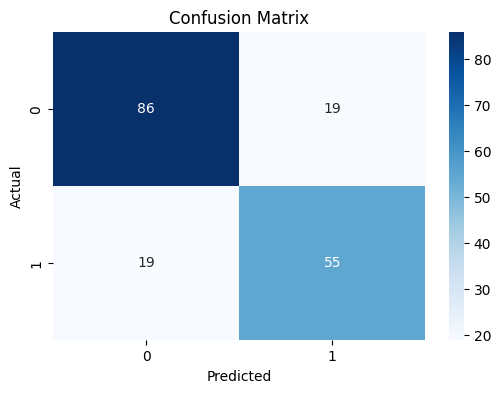

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Displaying feature importance
عرض أهمية المتغيرات المؤثرة في قرار النموذج



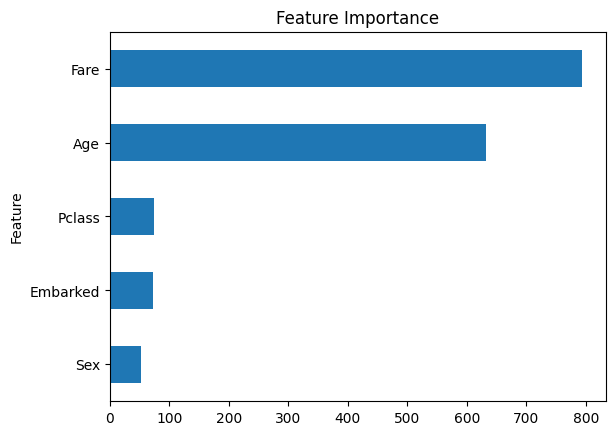

In [ ]:
importances = model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': list(importances.keys()),
    'Importance': list(importances.values())
})

importance_df.sort_values(by='Importance').plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance')
plt.show()

# Layan Ali
# 442803581